# 46 - Code Challenge: Deliberately Imbalanced MNIST

**Section:** Model Evaluation | **Prereqs:** `Model Evaluation/ARPF_MNIST.ipynb` | **Next:** `FNN Milestone Projects/FNN_HeartDisease.ipynb`

Cut the 7s down to a quarter of their original count and retrain. Overall accuracy
barely moves - the other nine digits carry it - but recall on the 7s falls
noticeably. This is the imbalance lesson from `More on Data/` with the metrics
from this section attached.

**What to read**
- `classification_report`: find the row for class 7 and compare its recall with
  the others.
- The **row-normalised** confusion matrix (`normalize='true'`): each row now sums
  to 1, so it reads as 'of all real 7s, what fraction went where?'. Without
  normalising, a rare class's row is dim simply because it is rare, and its error
  rate is invisible.

**The fixes** (worth trying as an exercise): class weights in
`CrossEntropyLoss(weight=...)`, a `WeightedRandomSampler`, oversampling the 7s
with augmentation, or lowering the decision threshold for that class.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

In [ ]:
# Colab's bundled small MNIST CSV. Column 0 is the label.
# Pixels are scaled to [0,1] before anything else - unscaled 0-255 inputs make
# the first layer's activations large and force an unnaturally small learning
# rate (see FNNs/MinMaxMNIST.ipynb).

data = np.loadtxt(open('sample_data/mnist_train_small.csv','rb'),delimiter=',')

train_label = data[:,0]
train_data  = data[:,1:] / 255.0


In [ ]:
# Split the 7s out from everything else.
seven_locs = train_data[train_label == 7]
seven_labels = train_label[train_label == 7]

train_data = train_data[train_label != 7]
train_label = train_label[train_label != 7]

In [ ]:
# Keep a random quarter of the 7s.
# replace=False matters: sampling with replacement would duplicate some 7s and
# drop others, so the class would be both thinned AND contain repeats - two
# effects tangled together in one experiment.
num = int(len(seven_locs)/4)
random_arr = np.random.choice(len(seven_locs), num, replace=False)

In [ ]:
seven_locs = torch.tensor(seven_locs[random_arr], dtype=torch.float, device='cuda')
seven_labels = torch.tensor(seven_labels[random_arr], dtype=torch.long, device='cuda')

In [ ]:
train_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Reassemble: the nine full classes plus the thinned 7s.
train_data = torch.tensor(train_data, dtype=torch.float, device='cuda')
train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')

train_data = torch.cat((train_data, seven_locs))
train_label = torch.cat((train_label, seven_labels))
train_data.shape, train_label.shape

(torch.Size([18405, 784]), torch.Size([18405]))

In [ ]:
# Count the classes - the check that should precede every classification run.
vals = pd.DataFrame(train_label.cpu()).value_counts()

In [ ]:
vals

,count
0,
1,2243
6,2039
9,2023
3,2021
2,1989
0,1962
4,1924
8,1912
5,1761


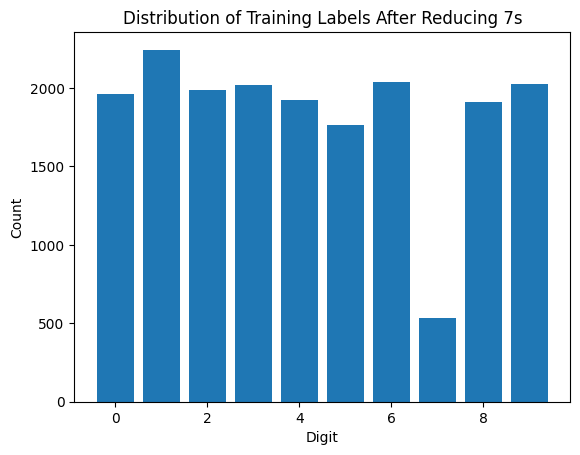

In [ ]:
# The imbalance, visible: nine bars of similar height and one at a quarter.
plt.bar([x[0] for x in vals.index], vals.values)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Training Labels After Reducing 7s')
plt.show()

In [ ]:
# 90/10 split, STRATIFIED on the label so both splits keep the same class
# proportions. Without it, a rare class can be over- or under-represented in the
# test split by chance, which is exactly the quantity being measured here.
train_data,test_data, train_labels,test_labels = train_test_split(train_data, train_label, test_size=.1, stratify=train_label.cpu())

train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])


In [ ]:
# 784-64-32-32-10, raw logits.
class Classifier(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

In [ ]:
# Standard training function, 10 epochs.
def train_model():

  model = Classifier().to('cuda')

  lossFunc = nn.CrossEntropyLoss()

  optimizer = torch.optim.SGD(model.parameters(),lr=.01)
  epochs = 10



  test_acc = []
  train_acc = []
  losses = []

  for i in range(epochs):

    model.train()
    batch_loss = []
    batch_acc = []

    for x,y in train_loader:

      x = x.to('cuda')
      y = y.to('cuda')

      yhat = model(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat, dim=1) == y).cpu().float() ))

    train_acc.append(np.mean(batch_acc))
    losses.append(np.mean(batch_loss))

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))

      X = X.to('cuda')
      Y = Y.to('cuda')

      preds = torch.argmax(model(X), dim=1)
      test_acc.append( 100 * torch.mean( (preds == Y).float().cpu()) )

    if i % 1 == 0 or i == epochs - 1 :
      print(f'Epochs {i} | Loss : {losses[i]} | Val Acc : {test_acc[i]}')


  return train_acc, test_acc, losses, model

In [ ]:
train_acc, test_acc, losses, model   = train_model()

Epochs 0 | Loss : 0.7404069651343376 | Val Acc : 85.55133056640625
Epochs 1 | Loss : 0.2902957696244265 | Val Acc : 90.54861450195312
Epochs 2 | Loss : 0.21773804380689935 | Val Acc : 92.8843002319336
Epochs 3 | Loss : 0.18622126118631266 | Val Acc : 92.28680419921875
Epochs 4 | Loss : 0.16124035384167323 | Val Acc : 93.42748260498047
Epochs 5 | Loss : 0.13556794420144083 | Val Acc : 94.45953369140625
Epochs 6 | Loss : 0.12736521882583285 | Val Acc : 93.59043884277344
Epochs 7 | Loss : 0.11492934679194593 | Val Acc : 93.31884765625
Epochs 8 | Loss : 0.10081346366510364 | Val Acc : 93.7533950805664
Epochs 9 | Loss : 0.09071486040713839 | Val Acc : 93.6990737915039


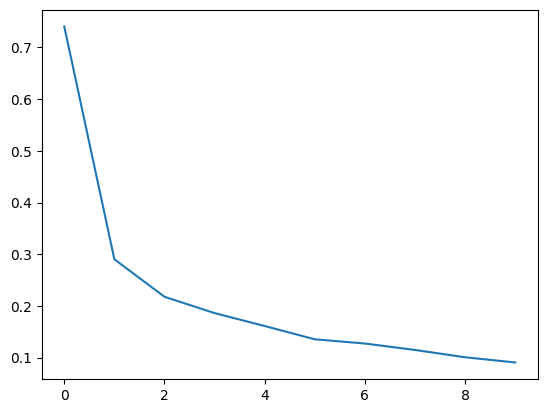

In [ ]:
# Loss curve.
plt.plot(losses);

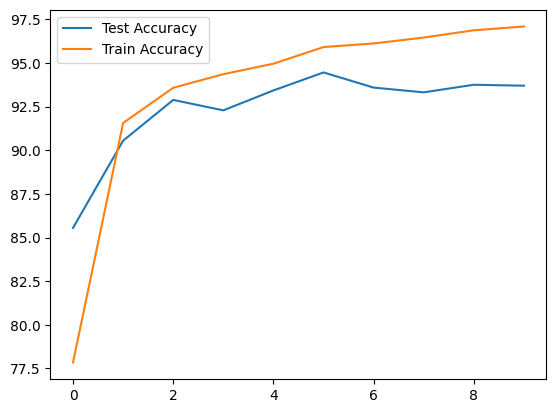

In [ ]:
# Accuracy curves. Both look healthy - which is precisely the trap. Overall
# accuracy is dominated by the nine well-represented digits.
plt.plot(test_acc, label="Test Accuracy")
plt.plot(train_acc, label='Train Accuracy')
plt.legend();

In [ ]:
# Move the model to CPU for evaluation so sklearn can consume the outputs.
model.cpu()
inp = train_loader.dataset.tensors[0].cpu()
train_preds = model(inp)

inp_test = test_loader.dataset.tensors[0].cpu()
test_preds = model(inp_test)


In [ ]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

In [ ]:
# argmax -> predicted class indices.
train_preds = torch.argmax(train_preds, dim=1).cpu()
train_label = train_loader.dataset.tensors[1].cpu()

test_preds = torch.argmax(test_preds, dim=1).cpu()
test_label = test_loader.dataset.tensors[1].cpu()

In [ ]:
# The test report. Go to the row for class 7: its recall is the number this
# whole notebook exists to show.
print(classification_report(test_label, test_preds))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       174
           1       0.97      0.95      0.96       209
           2       0.94      0.95      0.94       189
           3       0.90      0.99      0.95       201
           4       0.97      0.87      0.91       225
           5       0.96      0.92      0.94       157
           6       0.97      0.97      0.97       222
           7       0.94      0.80      0.86        60
           8       0.91      0.94      0.93       214
           9       0.85      0.91      0.88       190

    accuracy                           0.94      1841
   macro avg       0.94      0.93      0.93      1841
weighted avg       0.94      0.94      0.94      1841



In [ ]:
# The same on train. If recall on 7 is high here but low on test, the model
# memorised the few 7s it saw rather than learning what a 7 looks like.
print(classification_report(train_label, train_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1744
           1       0.99      0.99      0.99      2028
           2       0.97      0.99      0.98      1747
           3       0.98      0.97      0.97      1840
           4       0.96      0.99      0.98      1670
           5       0.94      0.99      0.97      1495
           6       1.00      0.97      0.98      1891
           7       0.92      0.95      0.93       371
           8       0.95      0.97      0.96      1671
           9       0.99      0.91      0.95      2012

    accuracy                           0.97     16469
   macro avg       0.97      0.97      0.97     16469
weighted avg       0.97      0.97      0.97     16469



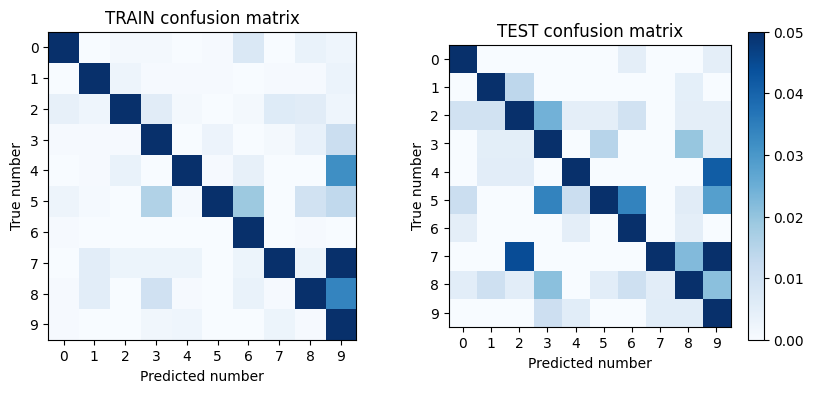

In [ ]:
# Confusion matrices with normalize='true': each ROW is divided by its total, so
# the values are 'of all real digit i, what fraction were predicted j'.
# This is essential for imbalanced data - raw counts make a rare class's row
# faint regardless of how badly it is being classified.
# Look along row 7 for where the missing 7s went.
# Confusion matrices
trainConf = confusion_matrix(train_label,train_preds,normalize='true')
testConf  = confusion_matrix(test_label, test_preds,normalize='true')

fig,ax = plt.subplots(1,2,figsize=(10,4))

# confmat during TRAIN
ax[0].imshow(trainConf,'Blues',vmax=.05)
ax[0].set_xticks(range(10))
ax[0].set_yticks(range(10))
ax[0].set_title('TRAIN confusion matrix')
ax[0].set_xlabel('True number')
ax[0].set_xlabel('Predicted number')
ax[0].set_ylabel('True number')

# confmat during TEST
a = ax[1].imshow(testConf,cmap='Blues',vmax=.05)
ax[1].set_xticks(range(10))
ax[1].set_yticks(range(10))
ax[1].set_title('TEST confusion matrix')
ax[1].set_xlabel('Predicted number')
ax[1].set_ylabel('True number')

fig.colorbar(a)
plt.show()

In [ ]:
precision_score(test_label,test_preds, average=None)[7]

np.float64(0.9459459459459459)

In [ ]:
recall_score(test_label,test_preds, average=None)[7]

np.float64(0.7777777777777778)

# Conclusion: The datset and how we divide data, can have an big impact on biases the model learns